## Что было сделано

**Данные:** 50 000 изображений лиц 256×256

Дисбаланс классов 83/17 - учитывала через WeightedRandomSampler и pos_weight в loss функции.

**Препроцессинг:** медианный фильтр убирает точечный шум с картинок
Аугментации: flip, rotation, color jitter, grayscale, gaussian blur

**Модели (все написаны с нуля):**
- ResNet-34 - baseline, residual блоки с двумя свертками = **0.874**
- ResNet-34 + FFT - добавила ветку которая смотрит на частотный домен картинки = **0.887**
- ResNet-34 + SE + FFT - добавила channel attention (SE-блоки) внутрь каждого блока = **0.935**
- ResNet-50 + SE + FFT - более глубокая сеть с Bottleneck блоками = **0.922**

**Дополнительно:**
- Подобрала порог: вместо дефолтного 0.5 нашла оптимальный 0.69
- TTA - каждую картинку прогоняла 6 раз с разными аугментациями
- Собрала ансамбль двух лучших моделей (60/40)

**Лучший результат на Kaggle: 0.956** (ансамбль ResNet-34+SE+FFT + ResNet-50+SE+FFT + TTA x6)

## 1. Импорты и конфиг

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
!pip install torchinfo -q
from torchinfo import summary

## 2. Загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/ml-intensive-yandex-academy-spring-2026.zip" -d /content/data/
!ls /content/data/

Mounted at /content/drive
dataset


## 3. Конфиг

In [ ]:
TRAIN_DIR = '/content/data/dataset/train_images'
TEST_DIR  = '/content/data/dataset/test_images'
CSV_PATH  = '/content/data/dataset/train_solution.csv'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
NUM_EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224

In [ ]:
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
print(f"Device: {DEVICE}")

Device: cuda


## 4. EDA

In [ ]:
df = pd.read_csv(CSV_PATH, header=None, names=['Id', 'target_feature'])
ID_COL = 'Id'
TARGET_COL = 'target_feature'

print(df.head())
print(df[TARGET_COL].value_counts())

   Id  target_feature
0   0               0
1   1               1
2   2               1
3   3               0
4   4               0
target_feature
0    41500
1     8500
Name: count, dtype: int64


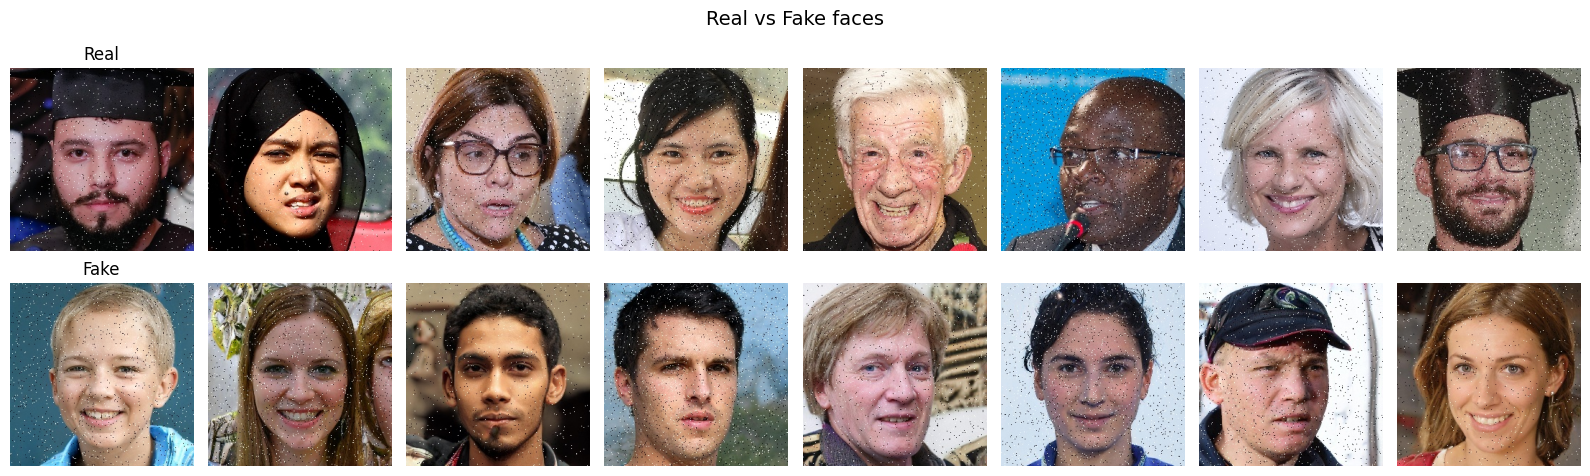

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for row, cls in enumerate([0, 1]):
    samples = df[df[TARGET_COL] == cls].sample(8, random_state=20)
    for col, (_, row_data) in enumerate(samples.iterrows()):
        img_path = os.path.join(TRAIN_DIR, f"{int(row_data[ID_COL])}.jpg")
        img = Image.open(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
    axes[row][0].set_title('Real' if cls == 0 else 'Fake', fontsize=12)

plt.suptitle('Real vs Fake faces', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Препроцессинг

In [ ]:
def remove_noise(img):
    img_np = np.array(img)
    img_filtered = cv2.medianBlur(img_np, 3)
    return Image.fromarray(img_filtered)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
samples = df.sample(4, random_state=SEED)
for col, (_, row) in enumerate(samples.iterrows()):
    img_path = os.path.join(TRAIN_DIR, f"{int(row[ID_COL])}.jpg")
    img = Image.open(img_path).convert('RGB')
    img_clean = remove_noise(img)
    axes[0][col].imshow(img)
    axes[0][col].set_title('original')
    axes[0][col].axis('off')
    axes[1][col].imshow(img_clean)
    axes[1][col].set_title('denoised')
    axes[1][col].axis('off')
plt.tight_layout()
plt.show()

## 6. Функции обучения

In [ ]:
def get_criterion(train_df):
    neg = (train_df[TARGET_COL] == 0).sum()
    pos = (train_df[TARGET_COL] == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(DEVICE)
    print(f"pos_weight: {pos_weight.item():.3f}")
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def get_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def get_scheduler(optimizer):
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += len(labels)
    return total_loss / total, correct / total

In [ ]:
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs).squeeze(1)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) > 0.5).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.long().cpu().numpy())
    f1 = f1_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), f1

In [ ]:
def plot_history(history, epoch):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f'Loss (epoch {epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history['val_f1'], color='#D85A30')
    axes[1].set_title(f'Val F1 (epoch {epoch})')
    axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

In [ ]:
def train(model, train_loader, val_loader, num_epochs, save_path):
    criterion = get_criterion(train_df)
    optimizer = get_optimizer(model)
    scheduler = get_scheduler(optimizer)
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1 = 0
    best_train_loss = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_f1 = val_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch:02d}/{num_epochs} | loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_f1 {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_train_loss = train_loss
            torch.save(model.state_dict(), save_path)
            print(f"saved (f1={best_f1:.4f})")

        if epoch % 5 == 0:
            plot_history(history, epoch)

    print(f"\nРезы")
    print(f"Best val F1:    {best_f1:.4f}")
    print(f"Train loss:     {best_train_loss:.4f}")
    print(f"Val loss (min): {min(history['val_loss']):.4f}")

    return history

## 7. Dataset и DataLoader

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{int(row[ID_COL])}.jpg")
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img, int(row[ID_COL])
        return img, torch.tensor(row[TARGET_COL], dtype=torch.float32)

In [ ]:
train_transform = transforms.Compose([
    transforms.Lambda(remove_noise),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Lambda(remove_noise),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df, val_df = train_test_split(
    df, test_size=0.1, stratify=df[TARGET_COL], random_state=SEED
)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

Train: 45000, Val: 5000


In [ ]:
class_counts = train_df[TARGET_COL].value_counts().to_dict()
sample_weights = [1 / class_counts[label] for label in train_df[TARGET_COL]]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dataset = FaceDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = FaceDataset(val_df, TRAIN_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## 8. Модель 1: ResNet-34

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(p=dropout_p)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

In [ ]:
class ResNet34(nn.Module):
    def __init__(self, dropout_p=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, 3, stride=1, dropout_p=dropout_p)
        self.layer2 = self._make_layer(64, 128, 4, stride=2, dropout_p=dropout_p)
        self.layer3 = self._make_layer(128, 256, 6, stride=2, dropout_p=dropout_p)
        self.layer4 = self._make_layer(256, 512, 3, stride=2, dropout_p=dropout_p)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout_fc = nn.Dropout(p=0.5)
        self.fc = nn.Linear(512, 1)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride, dropout_p):
        layers = [BasicBlock(in_channels, out_channels, stride=stride, dropout_p=dropout_p)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, dropout_p=dropout_p))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout_fc(x)
        return self.fc(x)

In [ ]:
model = ResNet34().to(DEVICE)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet34                                 [1, 1]                    --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Dropout2d: 3-4               [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-5                  [1, 64, 56, 56]           36,864
│ 

Классический ResNet-34 написанный с нуля
Основная идея - residual connections,
которые позволяют градиентам нормально течь через глубокую сеть, поэтомк каждый блок учит не полное преобразование, а только "поправку" к входу

Baseline для сравнения

pos_weight: 4.882


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/20 | loss 1.3984 | val_loss 1.7257 | val_f1 0.2906
saved (f1=0.2906)


  0%|          | 0/704 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 04/20 | loss 1.1261 | val_loss 1.2327 | val_f1 0.3521
saved (f1=0.3521)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 05/20 | loss 1.0054 | val_loss 1.2237 | val_f1 0.3674
saved (f1=0.3674)


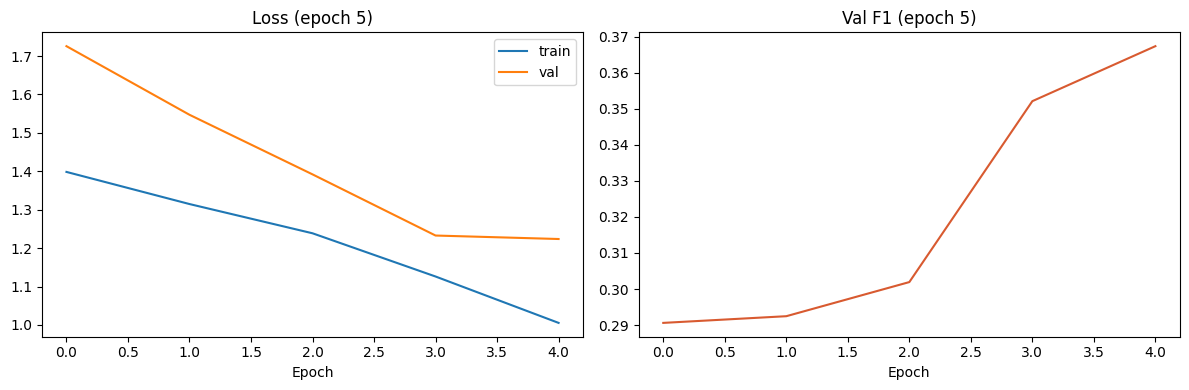

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 06/20 | loss 0.8982 | val_loss 0.9358 | val_f1 0.4289
saved (f1=0.4289)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 09/20 | loss 0.6178 | val_loss 0.6122 | val_f1 0.5861
saved (f1=0.5861)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/20 | loss 0.5343 | val_loss 0.6220 | val_f1 0.5796


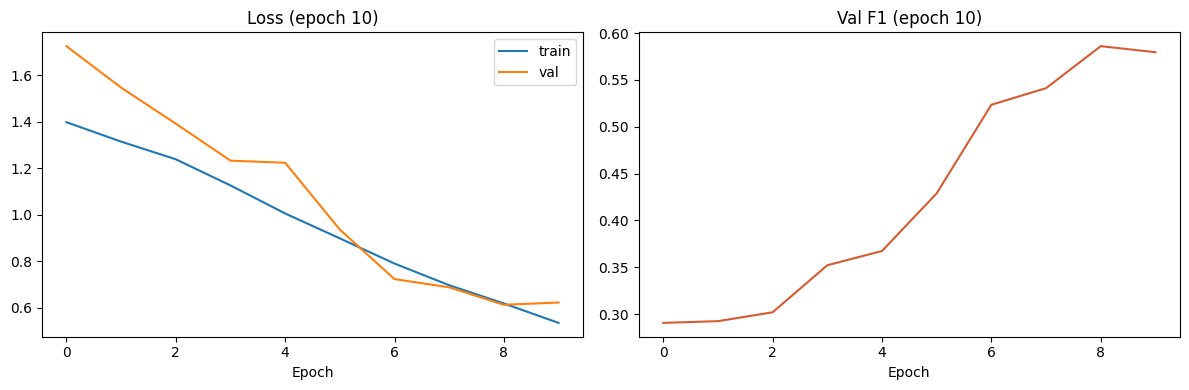

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 11/20 | loss 0.4784 | val_loss 0.6045 | val_f1 0.6018
saved (f1=0.6018)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/20 | loss 0.3225 | val_loss 0.4260 | val_f1 0.7525
saved (f1=0.7525)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/20 | loss 0.2881 | val_loss 0.4570 | val_f1 0.7156


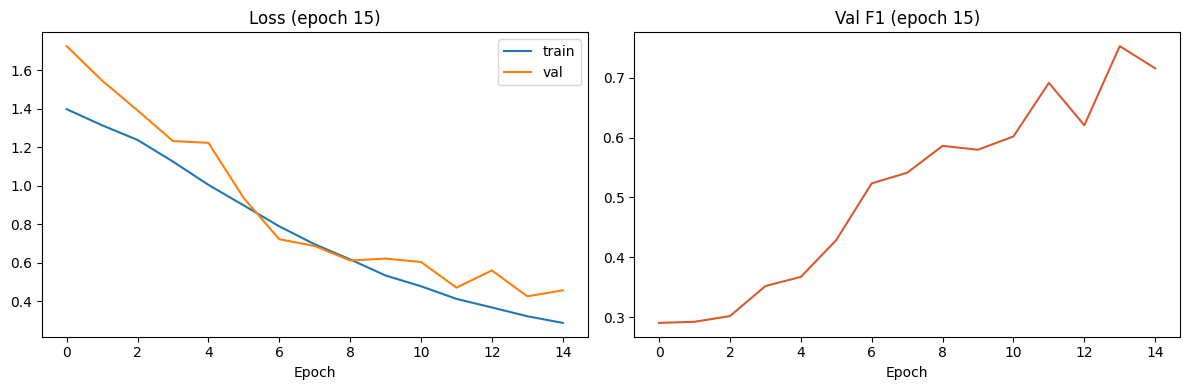

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 16/20 | loss 0.2527 | val_loss 0.3997 | val_f1 0.7665
saved (f1=0.7665)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/20 | loss 0.1731 | val_loss 0.4466 | val_f1 0.7718
saved (f1=0.7718)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/20 | loss 0.1616 | val_loss 0.4186 | val_f1 0.7966
saved (f1=0.7966)


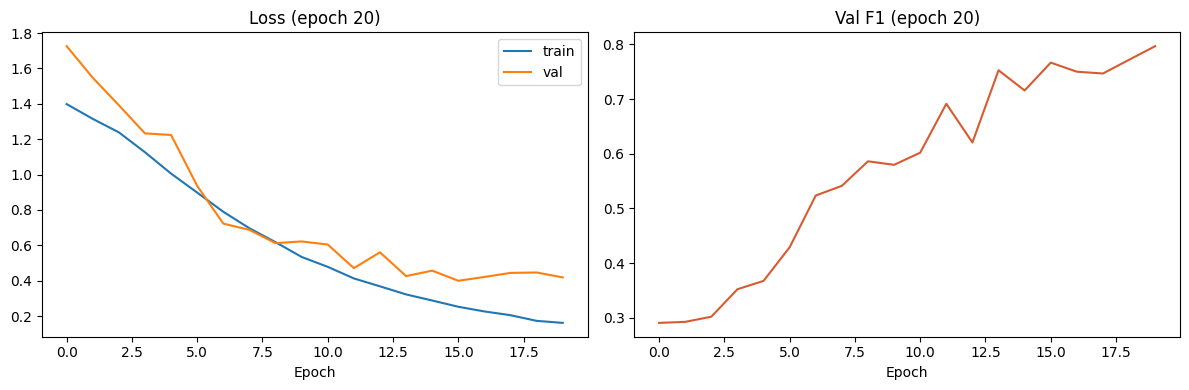


Резы
Best val F1:    0.7966
Train loss:     0.1616
Val loss (min): 0.3997


In [ ]:
history = train(model, train_loader, val_loader, 20, '/content/drive/MyDrive/resnet34.pth')

## 9. Модель 2: ResNet-34 + FFT

In [ ]:
class FrequencyBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        fft = torch.fft.fft2(x, norm='ortho')
        fft = torch.abs(fft)
        fft = torch.log1p(fft)
        return self.conv(fft).flatten(1)

In [ ]:
class ResNet34WithFFT(nn.Module):

    def __init__(self, dropout_p=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, 3, stride=1, dropout_p=dropout_p)
        self.layer2 = self._make_layer(64, 128, 4, stride=2, dropout_p=dropout_p)
        self.layer3 = self._make_layer(128, 256, 6, stride=2, dropout_p=dropout_p)
        self.layer4 = self._make_layer(256, 512, 3, stride=2, dropout_p=dropout_p)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.freq_branch = FrequencyBranch()
        self.dropout_fc = nn.Dropout(p=0.5)
        self.fc = nn.Linear(512 + 128, 1)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride, dropout_p):
        layers = [BasicBlock(in_channels, out_channels, stride=stride, dropout_p=dropout_p)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, dropout_p=dropout_p))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        freq = self.freq_branch(x)
        out = torch.cat([out, freq], dim=1)
        out = self.dropout_fc(out)
        return self.fc(out)

In [ ]:
model_fft = ResNet34WithFFT().to(DEVICE)
summary(model_fft, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet34WithFFT                          [1, 1]                    --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Dropout2d: 3-4               [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-5                  [1, 64, 56, 56]           36,864
│ 

StyleGAN при генерации оставляет характерные артефакты в частотном домене, которые глазами естественно не видно, но FFT показывает

Добавила параллельную ветку которая смотрит на
частотное представление картинки, а потом склеила с основными признаками

pos_weight: 4.882


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/25 | loss 1.3812 | val_loss 1.7255 | val_f1 0.2906
saved (f1=0.2906)


  0%|          | 0/704 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 04/25 | loss 1.1113 | val_loss 1.3513 | val_f1 0.3358
saved (f1=0.3358)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 05/25 | loss 1.0584 | val_loss 1.0097 | val_f1 0.4060
saved (f1=0.4060)


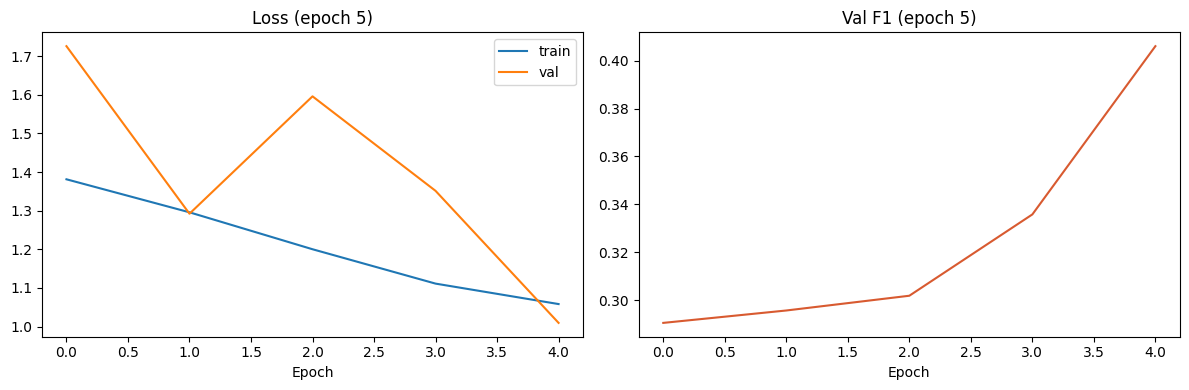

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 06/25 | loss 0.9804 | val_loss 1.4819 | val_f1 0.3502


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 09/25 | loss 0.7426 | val_loss 0.8778 | val_f1 0.4731
saved (f1=0.4731)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/25 | loss 0.6609 | val_loss 1.0994 | val_f1 0.4223


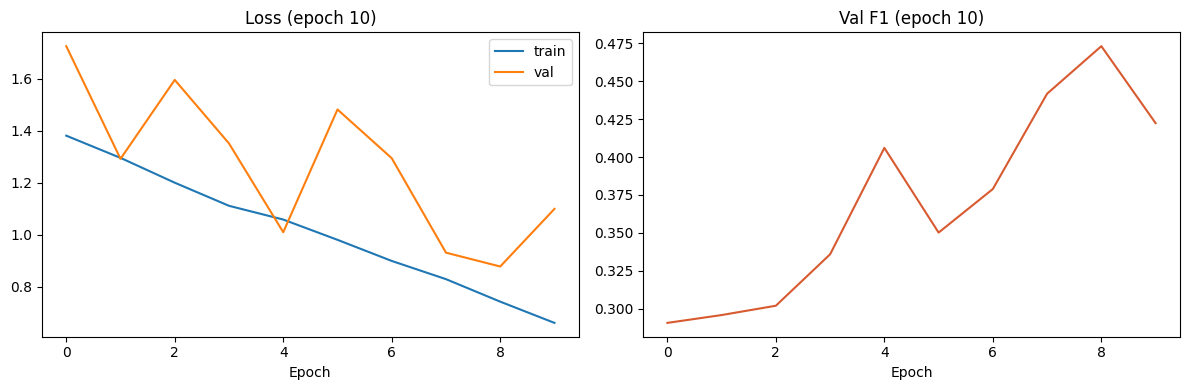

  0%|          | 0/704 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bebcb19fba0><function _MultiProcessingDataLoaderIter.__del__ at 0x7bebcb19fba0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():
if w.is_alive(): 
            ^ ^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 11/25 | loss 0.5893 | val_loss 0.8787 | val_f1 0.5054
saved (f1=0.5054)


  0%|          | 0/704 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/25 | loss 0.4168 | val_loss 0.7422 | val_f1 0.5513


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/25 | loss 0.3810 | val_loss 0.4919 | val_f1 0.6903


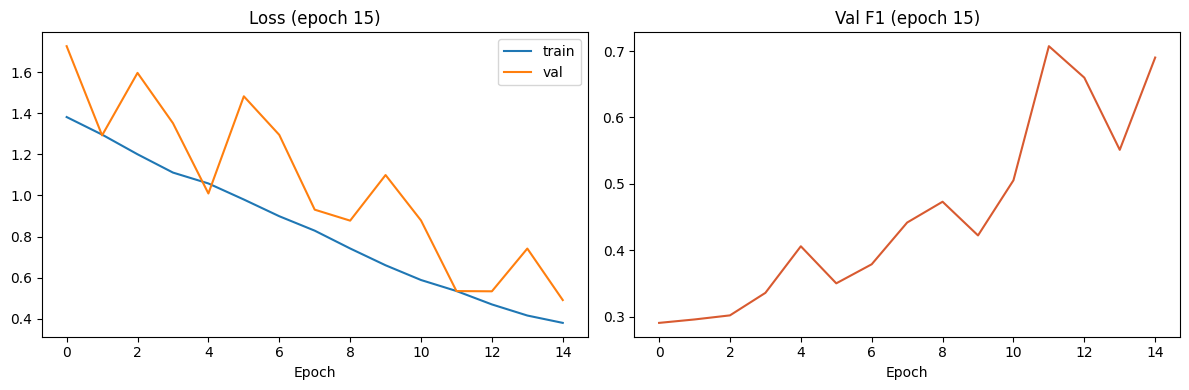

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 16/25 | loss 0.3274 | val_loss 0.5048 | val_f1 0.6792


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/25 | loss 0.2289 | val_loss 0.4356 | val_f1 0.7701
saved (f1=0.7701)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/25 | loss 0.2062 | val_loss 0.4503 | val_f1 0.7376


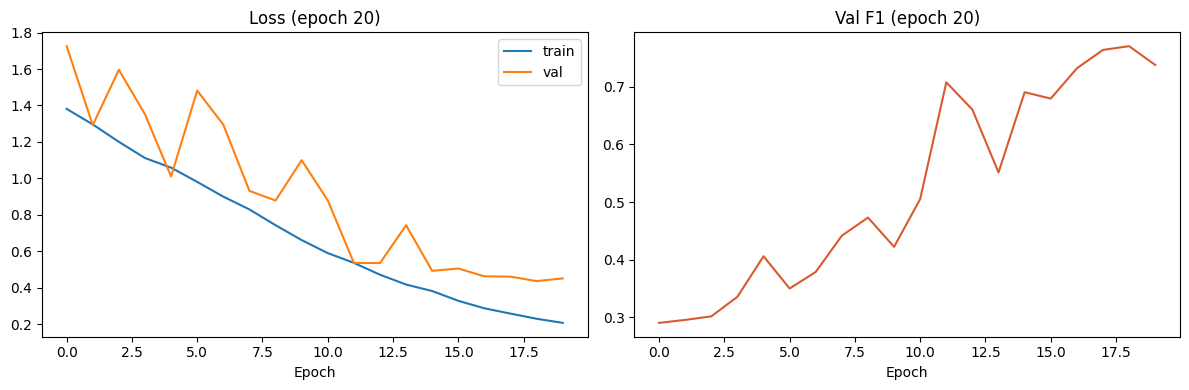

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 21/25 | loss 0.1737 | val_loss 0.4025 | val_f1 0.7820
saved (f1=0.7820)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 23/25 | loss 0.1373 | val_loss 0.4052 | val_f1 0.8145
saved (f1=0.8145)


  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/25 | loss 0.1278 | val_loss 0.3982 | val_f1 0.7882


  0%|          | 0/704 [00:00<?, ?it/s]

In [ ]:
history_fft = train(model_fft, train_loader, val_loader, 25, '/content/drive/MyDrive/resnet34_fft.pth')

## 10. Модель 3: ResNet-34 + SE + FFT (лучшая модель)

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.squeeze(x).view(b, c)
        w = self.excitation(w).view(b, c, 1, 1)
        return x * w

In [ ]:
class BasicBlockSE(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(p=dropout_p)
        self.se = SEBlock(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        return self.relu(out)

In [ ]:
class FrequencyBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        fft = torch.fft.fft2(x, norm='ortho')
        fft = torch.abs(fft)
        fft = torch.log1p(fft)
        return self.conv(fft).flatten(1)


In [ ]:
class ResNet34SEFFT(nn.Module):

    def __init__(self, dropout_p=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, 3, stride=1, dropout_p=dropout_p)
        self.layer2 = self._make_layer(64, 128, 4, stride=2, dropout_p=dropout_p)
        self.layer3 = self._make_layer(128, 256, 6, stride=2, dropout_p=dropout_p)
        self.layer4 = self._make_layer(256, 512, 3, stride=2, dropout_p=dropout_p)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.freq_branch = FrequencyBranch()
        self.dropout_fc = nn.Dropout(p=0.5)
        self.fc = nn.Linear(512 + 128, 1)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride, dropout_p):
        layers = [BasicBlockSE(in_channels, out_channels, stride=stride, dropout_p=dropout_p)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlockSE(out_channels, out_channels, dropout_p=dropout_p))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        freq = self.freq_branch(x)
        out = torch.cat([out, freq], dim=1)
        out = self.dropout_fc(out)
        return self.fc(out)

In [ ]:
train_dataset = FaceDataset(train_df, TRAIN_DIR, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)

model_se_fft = ResNet34SEFFT().to(DEVICE)
print(f"Params: {sum(p.numel() for p in model_se_fft.parameters()):,}")

Params: 21,535,969


Добавила SE-блоки внутрь каждого residual блока

SE смотрит на все каналы и расставляет веса — какие признаки важнее, какие нет

Модель сама решает на что обращать внимание, по итогоу это лучшая модель, графики обучения котороя я благополучно потеряла)))

In [ ]:
history_se_fft = train(model_se_fft, train_loader, val_loader, 30,
                       '/content/drive/MyDrive/resnet34_se_fft.pth')

убого, но ячейку с обучением именной этой модели я потеряла, потому что на кагле случайно в ноутбуке перезапустила, веса есть

## 11. Модель 4: ResNet-50 + SE + FFT

In [ ]:
class BottleneckSE(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * 4, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * 4)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(p=dropout_p)
        self.se = SEBlock(out_channels * 4)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * 4:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * 4, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * 4)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        out = self.bn3(self.conv3(out))
        out = self.se(out)
        out += self.shortcut(x)
        return self.relu(out)

In [ ]:
class ResNet50SEFFT(nn.Module):
    def __init__(self, dropout_p=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, 3, stride=1, dropout_p=dropout_p)
        self.layer2 = self._make_layer(256, 128, 4, stride=2, dropout_p=dropout_p)
        self.layer3 = self._make_layer(512, 256, 6, stride=2, dropout_p=dropout_p)
        self.layer4 = self._make_layer(1024, 512, 3, stride=2, dropout_p=dropout_p)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.freq_branch = FrequencyBranch()
        self.dropout_fc = nn.Dropout(p=0.5)
        self.fc = nn.Linear(2048 + 128, 1)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride, dropout_p):
        layers = [BottleneckSE(in_channels, out_channels, stride=stride, dropout_p=dropout_p)]
        for _ in range(1, num_blocks):
            layers.append(BottleneckSE(out_channels * 4, out_channels, dropout_p=dropout_p))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        freq = self.freq_branch(x)
        out = torch.cat([out, freq], dim=1)
        out = self.dropout_fc(out)
        return self.fc(out)

In [ ]:
train_dataset = FaceDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = FaceDataset(val_df, TRAIN_DIR, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model_50 = ResNet50SEFFT().to(DEVICE)
print(f"Params: {sum(p.numel() for p in model_50.parameters()):,}")

Params: 26,118,625


Более глубокая версия с Bottleneck блоками: три свёртки (1x1-3x3-1x1) вместо двух


Плюс добавила препроцессинг: медианный фильтр убирает точечный шум с картинок
перед подачей в модель

In [ ]:
history_50 = train(model_50, train_loader, val_loader, 30,
                   '/content/drive/MyDrive/resnet50_se_fft.pth')

pos_weight: 4.882

Epoch 01/30 | loss 1.2804 | val_loss 1.2475 | val_f1 0.3350
saved (f1=0.3350)

Epoch 02/30 | loss 1.0432 | val_loss 1.1315 | val_f1 0.3715
saved (f1=0.3715)

Epoch 03/30 | loss 0.9284 | val_loss 1.1982 | val_f1 0.4103
saved (f1=0.4103)

Epoch 04/30 | loss 0.8250 | val_loss 1.1988 | val_f1 0.3948

Epoch 05/30 | loss 0.7367 | val_loss 0.8021 | val_f1 0.5068
saved (f1=0.5068)

Epoch 06/30 | loss 0.6605 | val_loss 0.7864 | val_f1 0.4868

Epoch 07/30 | loss 0.5905 | val_loss 0.5333 | val_f1 0.6418
saved (f1=0.6418)

Epoch 08/30 | loss 0.5251 | val_loss 0.4751 | val_f1 0.6821
saved (f1=0.6821)

Epoch 09/30 | loss 0.4635 | val_loss 0.4676 | val_f1 0.7108
saved (f1=0.7108)

Epoch 10/30 | loss 0.4223 | val_loss 0.4513 | val_f1 0.6860

Epoch 11/30 | loss 0.3828 | val_loss 0.4442 | val_f1 0.7006

Epoch 12/30 | loss 0.3355 | val_loss 0.4576 | val_f1 0.6886

Epoch 13/30 | loss 0.3029 | val_loss 0.4725 | val_f1 0.6929

Epoch 14/30 | loss 0.2778 | val_loss 0.3889 | val_f1 0.7340
sa

### Дообучение ResNet-50 ещё 15 эпох с lr=1e-4

30 эпох не хватило, поэтому дообучила еще на 15

In [ ]:
def get_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)

def get_scheduler(optimizer):
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

model_50.load_state_dict(torch.load('/content/drive/MyDrive/resnet50_se_fft.pth', map_location=DEVICE))
history_50_v2 = train(model_50, train_loader, val_loader, 15,
                      '/content/drive/MyDrive/resnet50_se_fft_v2.pth')

pos_weight: 4.882

Epoch 01/15 | loss 0.0713 | val_loss 0.3487 | val_f1 0.8622
saved (f1=0.8622)

Epoch 02/15 | loss 0.0709 | val_loss 0.3234 | val_f1 0.8675
saved (f1=0.8675)

Epoch 03/15 | loss 0.0687 | val_loss 0.3437 | val_f1 0.8727
saved (f1=0.8727)

Epoch 04/15 | loss 0.0643 | val_loss 0.3572 | val_f1 0.8743
saved (f1=0.8743)

Epoch 05/15 | loss 0.0624 | val_loss 0.3592 | val_f1 0.8685

Epoch 06/15 | loss 0.0614 | val_loss 0.3616 | val_f1 0.8658

Epoch 07/15 | loss 0.0603 | val_loss 0.3591 | val_f1 0.8815
saved (f1=0.8815)

Epoch 08/15 | loss 0.0532 | val_loss 0.3460 | val_f1 0.8714

Epoch 09/15 | loss 0.0527 | val_loss 0.3616 | val_f1 0.8814

Epoch 10/15 | loss 0.0486 | val_loss 0.3624 | val_f1 0.8858
saved (f1=0.8858)

Epoch 11/15 | loss 0.0471 | val_loss 0.3616 | val_f1 0.8880
saved (f1=0.8880)

Epoch 12/15 | loss 0.0482 | val_loss 0.3578 | val_f1 0.8832

Epoch 13/15 | loss 0.0445 | val_loss 0.3423 | val_f1 0.8798

Epoch 14/15 | loss 0.0435 | val_loss 0.3472 | val_f1 0.8827

E

## 12. Подбор порога

In [ ]:
all_probs_val, all_labels_val = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader):
        imgs = imgs.to(DEVICE)
        logits = model_se_fft(imgs).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs_val.extend(probs)
        all_labels_val.extend(labels.numpy())

all_probs_val = np.array(all_probs_val)
all_labels_val = np.array(all_labels_val)

best_threshold, best_f1 = 0.5, 0
for threshold in np.arange(0.3, 0.7, 0.01):
    preds = (all_probs_val > threshold).astype(int)
    f1 = f1_score(all_labels_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best threshold: {best_threshold:.2f}, F1: {best_f1:.4f}")

тут тоже результат потерялся, но порог 0.69

## 13. Финал: TTA + ансамбль (лучший результат: 0.956)

In [ ]:
from google.colab import files

# загружаем веса обеих моделей
uploaded = files.upload()

model_se_fft = ResNet34SEFFT().to(DEVICE)
model_se_fft.load_state_dict(torch.load('resnet34_se_fft.pth', map_location=DEVICE))
model_se_fft.eval()

model_50 = ResNet50SEFFT().to(DEVICE)
model_50.load_state_dict(torch.load('resnet50_se_fft.pth', map_location=DEVICE))
model_50.eval()

In [ ]:
tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Lambda(remove_noise),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Lambda(remove_noise),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Lambda(remove_noise),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Lambda(remove_noise),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Lambda(remove_noise),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomRotation(degrees=(5, 5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
]

def get_tta_probs(model, tta_transforms):
    all_probs = None
    for transform in tta_transforms:
        test_df = pd.DataFrame({'Id': range(10000)})
        test_dataset = FaceDataset(test_df, TEST_DIR, transform=transform, is_test=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        probs_tta = []
        with torch.no_grad():
            for imgs, img_ids in tqdm(test_loader):
                imgs = imgs.to(DEVICE)
                logits = model(imgs).squeeze(1)
                probs = torch.sigmoid(logits).cpu().numpy()
                probs_tta.extend(probs)
        probs_tta = np.array(probs_tta)
        if all_probs is None:
            all_probs = probs_tta
        else:
            all_probs += probs_tta
    return all_probs / len(tta_transforms)

probs_34 = get_tta_probs(model_se_fft, tta_transforms)
probs_50 = get_tta_probs(model_50, tta_transforms)

ensemble_probs = (0.6 * probs_34 + 0.4 * probs_50)

preds = (ensemble_probs > 0.69).astype(int)
submission = pd.DataFrame({'id': range(10000), 'target_feature': preds})
submission = submission.sort_values('id').reset_index(drop=True)
submission.to_csv('/content/drive/MyDrive/submission_ensemble.csv', index=False)

from google.colab import files
files.download('/content/drive/MyDrive/submission_ensemble.csv')

Усреднение предсказаний двух моделей (60% ResNet-34, 40% ResNet-50)

TTA — каждую тестовую картинку прогоняю 6 раз с разными аугментациями и усредняю результат

Итоговый результат на Kaggle:  0.95579

оч обидно, что потеряла графики, но уже просто не успеваю заново обучить ее...